# Survival function: empirical vs analytic

Reproduces the two-panel appendix figure (`fig:theoretical_vs_empirical_survival_function`): the matched-filter detection probability $p(\rho_{\rm mf}>\rho_{\rm th}\,|\,\theta)$ estimated **empirically** (red band) versus the **analytic** non-central $\chi^2$ survival function (blue), for eccentric and quasicircular injections.

The empirical band is a bootstrap mean $\pm$ std over the noise realisations. It is wide because each sample carries only `n_noise = 60` noise draws (the wide-band, many-samples variant: ~2200 eccentric / ~2400 quasicircular stratified samples). The eccentric injections use genuinely eccentric SEOBNRv5EHM waveforms (high-$e$ draws that fall outside the model's domain of validity are dropped). Data: `zenodo_data/selection_function/survival_function.h5`.

In [1]:
import os, sys
import numpy as np
import h5py
import scipy.stats
import matplotlib.pyplot as plt

sys.path.append(os.path.join('..', 'scripts'))
sys.path.append(os.path.join('..', 'style'))
from config import SELECTION_DIR
from plot_style import initialize_latex, COLORS

initialize_latex()
H5 = os.path.join(SELECTION_DIR, 'survival_function.h5')

def marcumq(nu, a, b):
    # Non-central chi^2 survival function (generalised Marcum Q).
    return scipy.stats.ncx2.sf(b ** 2, 2 * nu, a ** 2)

def bootstrap_survival(arr, threshold, n_boot=100, rng=None):
    rng = rng or np.random.default_rng()
    boots = rng.choice(arr, (n_boot, len(arr)), replace=True)
    surv = (boots > threshold).mean(axis=1)
    return surv.mean(), surv.std()

In [2]:
def plot_survival(case, title, outfile, rho_ths=(8, 10, 12), ifo_list=('H1', 'L1'),
                  xlim=(4, 14), ylim=(1e-2, 1.0), seed=0,
                  xlabel=r'$\rho_{\mathrm{eff, opt}}$'):
    with h5py.File(H5, 'r') as f:
        if case not in f:
            print(f'{case!r} not in {H5} -- run convert_data.py survival after the QC MF job')
            return None
        x = f[case]['x'][:]
        mf = f[case]['mf_snrs'][:]
    order = np.argsort(x)
    x, mf = x[order], mf[order]
    rng = np.random.default_rng(seed)
    nu = len(ifo_list) / 2.0
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title(title)
    for rho_th in rho_ths:
        ana = marcumq(nu, x, rho_th)
        vals = np.empty(len(x)); stds = np.empty(len(x))
        for i in range(len(x)):
            vals[i], stds[i] = bootstrap_survival(mf[i], rho_th, rng=rng)
        ax.fill_between(x, vals - stds, vals + stds, color=COLORS['red'], alpha=0.15, lw=0, zorder=1)
        ax.plot(x, vals - stds, color=COLORS['red'], lw=0.6, alpha=0.35, zorder=1)
        ax.plot(x, vals + stds, color=COLORS['red'], lw=0.6, alpha=0.35, zorder=1)
        ax.plot(x, ana, color=COLORS['blue'], lw=2, zorder=3)
        ax.text(rho_th - 2.3, 0.1, rf'$\rho_{{\mathrm{{th}}}}={int(rho_th)}$', fontsize=16)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_yscale('log')
    # For quasicircular injections the best-fit QC template recovers essentially
    # all of the signal power, so the effective optimal SNR equals the optimal
    # SNR -- label it rho_opt. The eccentric panel keeps rho_eff_opt because the
    # QC bank only captures a fraction (the fitting factor) of an eccentric signal.
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(r'$p(\rho_{\mathrm{mf}} > \rho_{\mathrm{th}}\,|\,\theta)$', fontsize=16)
    handles = [plt.Line2D([0], [0], color=COLORS['blue'], lw=3, label='Analytical'),
               plt.Line2D([0], [0], color=COLORS['red'], lw=3, alpha=0.5, label='Empirical envelope')]
    ax.legend(handles=handles, fontsize=14)
    os.makedirs('../figures', exist_ok=True)
    fig.savefig(os.path.join('..', 'figures', outfile), dpi=300, bbox_inches='tight')
    print('wrote', outfile)
    return fig

wrote survival_function_ecc_injections.pdf


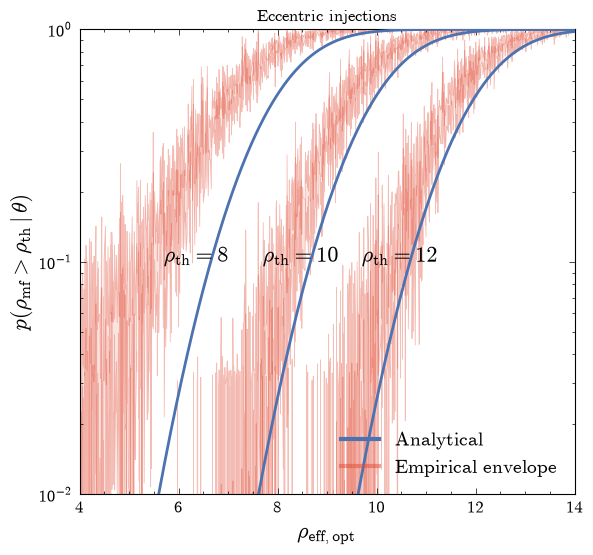

In [3]:
plot_survival('eccentric', 'Eccentric injections', 'survival_function_ecc_injections.pdf');

wrote survival_function_quasicircular_injections.pdf


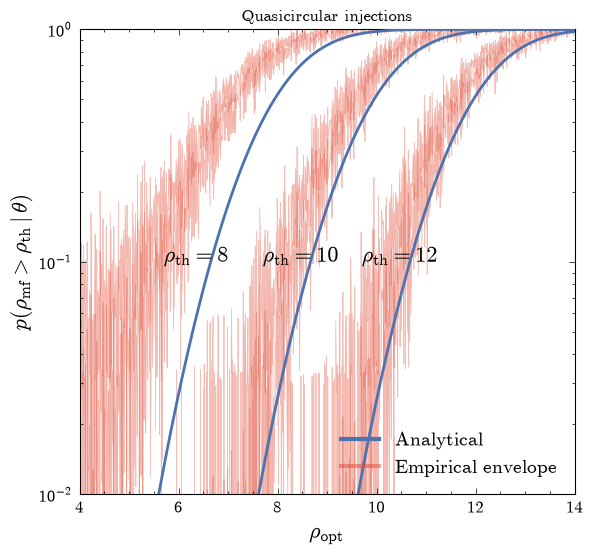

In [4]:
plot_survival('quasicircular', 'Quasicircular injections', 'survival_function_quasicircular_injections.pdf',
              xlabel=r'$\rho_{\mathrm{opt}}$');

## Eccentricity-stratified survival: the bank-maximization effect

The pooled eccentric panel above closely tracks the analytic non-central $\chi^2$ — but that is because the $x$-axis is $\rho_{\rm eff,opt}$, the *best-template* (post-bank) effective SNR, which already absorbs the fitting-factor loss. The physics the appendix figure is really probing only shows up when we **stratify by eccentricity**.

The plot below overlays the survival bands for quasicircular ($e=0$), $0 < e < 0.4$ and $0.4 \leq e < 0.8$ injections (one colour each), binned in $\rho_{\rm eff,opt}$ so the series are legible together. The $e=0$ band hugs the analytic non-central $\chi^2$ (dashed) — as expected, since a quasicircular signal is matched by a single dominant template. As eccentricity grows the best template has only modest overlap, many *widely separated* templates match comparably, their filter outputs are correlated, and maximizing the SNR over the bank lets noise fluctuations play a larger role — so the empirical band lifts progressively **above** the analytic curve, most for the high-$e$ ($0.4 \leq e < 0.8$) injections.

wrote survival_function_eccentricity_stratified.pdf


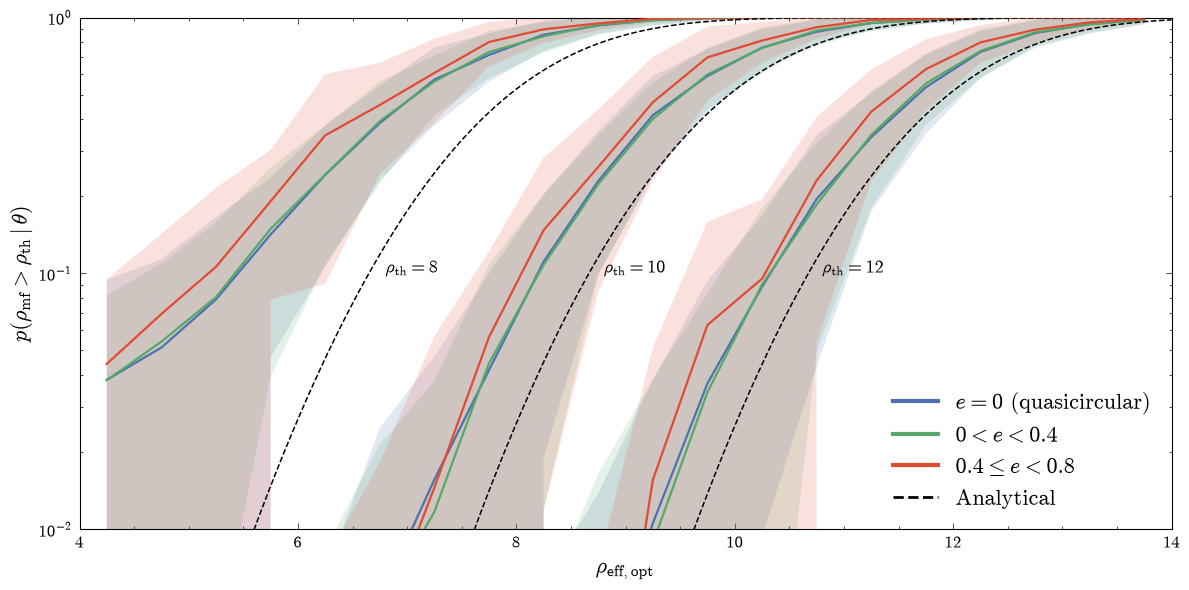

In [5]:
def plot_survival_stratified(rho_ths=(8, 10, 12), ifo_list=('H1', 'L1'),
                             x_edges=np.linspace(4, 14, 21), xlim=(4, 14), ylim=(1e-2, 1.0),
                             n_sigma=2, figsize=(12, 6),
                             outfile='survival_function_eccentricity_stratified.pdf'):
    """Single axis: the survival bands for quasicircular (e=0), 0 < e < 0.4 and
    0.4 <= e < 0.8 injections overlaid in different colours. Each band is the
    mean +/- n_sigma * std of the per-injection survival p(rho_mf > rho_th) within each
    rho_eff_opt bin (binned so the series are legible together). The e=0 series hugs the
    analytic non-central chi^2 (dashed); as e grows the band lifts above it, because a
    quasicircular bank recovering out-of-model eccentric signals maximizes over many
    widely-separated, comparably overlapping templates and noise inflates the recovered
    SNR. Needs the per-sample 'eccentricity' dataset in survival_function.h5."""
    with h5py.File(H5, 'r') as f:
        if 'eccentricity' not in f['eccentric']:
            print("'eccentric' has no 'eccentricity' dataset -- regenerate survival_function.h5")
            return None
        ex = f['eccentric']['x'][:]; emf = f['eccentric']['mf_snrs'][:]
        ecc = f['eccentric']['eccentricity'][:]
        qx = f['quasicircular']['x'][:]; qmf = f['quasicircular']['mf_snrs'][:]
    nu = len(ifo_list) / 2.0
    ctr = 0.5 * (x_edges[:-1] + x_edges[1:])
    xa = np.linspace(xlim[0], xlim[1], 300)
    groups = [(r'$e = 0$ (quasicircular)', qx, qmf, COLORS['blue']),
              (r'$0 < e < 0.4$', ex[ecc < 0.4], emf[ecc < 0.4], COLORS['green']),
              (r'$0.4 \leq e < 0.8$', ex[ecc >= 0.4], emf[ecc >= 0.4], COLORS['red'])]

    fig, ax = plt.subplots(figsize=figsize)
    for rho_th in rho_ths:
        ax.plot(xa, marcumq(nu, xa, rho_th), color='black', ls='--', lw=1.1, zorder=5)
        ax.text(rho_th - 1.2, 0.1, rf'$\rho_{{\mathrm{{th}}}}={int(rho_th)}$', fontsize=13, color='black')
    for label, xs, mfs, c in groups:
        for rho_th in rho_ths:
            mean = np.full(len(ctr), np.nan); std = np.full(len(ctr), np.nan)
            for i in range(len(ctr)):
                m = (xs >= x_edges[i]) & (xs < x_edges[i + 1])
                if m.sum() >= 5:
                    surv = (mfs[m] > rho_th).mean(axis=1)   # per-injection survival
                    mean[i], std[i] = surv.mean(), surv.std()
            ax.fill_between(ctr, mean - n_sigma * std, mean + n_sigma * std,
                            color=c, alpha=0.16, lw=0, zorder=2)
            ax.plot(ctr, mean, color=c, lw=1.6, zorder=3)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_yscale('log')
    ax.set_xlabel(r'$\rho_{\mathrm{eff, opt}}$', fontsize=16)
    ax.set_ylabel(r'$p(\rho_{\mathrm{mf}} > \rho_{\mathrm{th}}\,|\,\theta)$', fontsize=16)
    handles = [plt.Line2D([0], [0], color=c, lw=3, label=label) for label, _, _, c in groups]
    handles.append(plt.Line2D([0], [0], color='black', ls='--', lw=2, label='Analytical'))
    ax.legend(handles=handles, fontsize=16, loc='lower right')
    fig.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    fig.savefig(os.path.join('..', 'figures', outfile), dpi=300, bbox_inches='tight')
    print('wrote', outfile)
    return fig

plot_survival_stratified();